### UMAP Visualization of SmaAT-UNet-VQ Bottleneck Features


In [1]:
%matplotlib widget

/home/nstavrou/.local/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.2.5, which is newer than your current Lightning version: v2.2.1


[VQ] input shape after flattening = (2592, 512)
After flatten: pre_flat.shape = (2592, 512),  post_flat.shape = (2592, 512)


/home/nstavrou/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/nstavrou/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nstavrou/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


After UMAP: embedding_pre.shape = (2592, 2),  embedding_post.shape = (2592, 2)


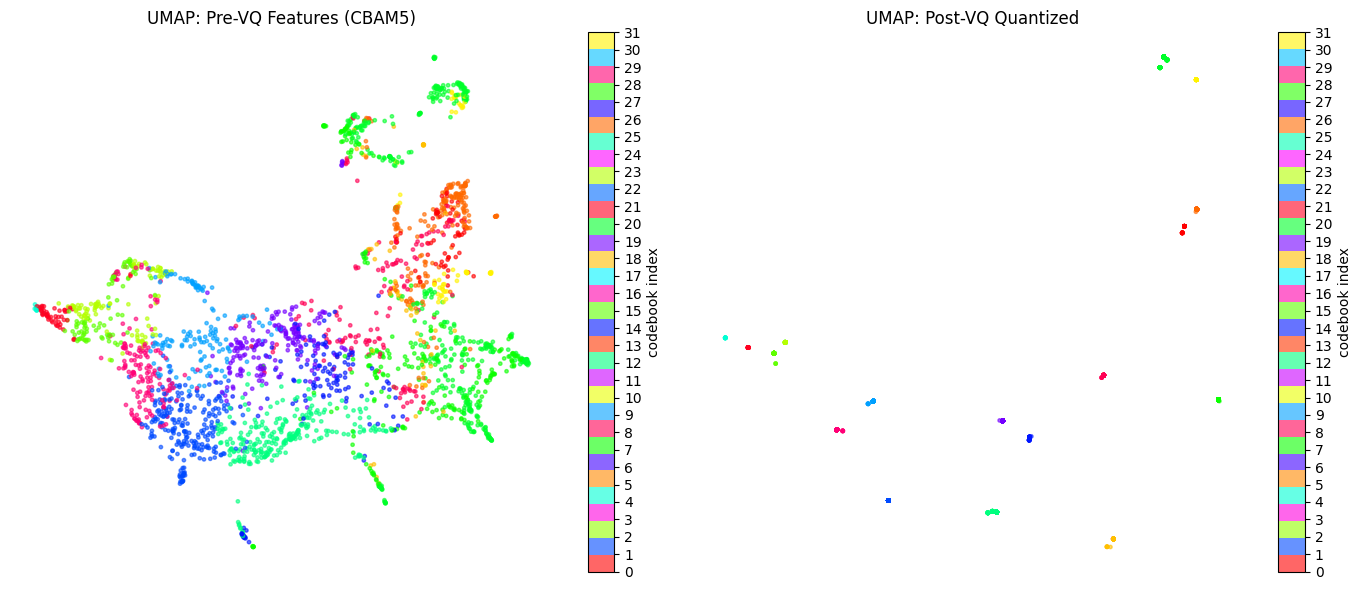

In [1]:
# 1) Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import umap
import argparse

from utils import dataset_precip
from models import SmaAT_UNet_VQ_lightning

# %% 
# 2) Hyperparameters & checkpoint
hparams = argparse.Namespace(
    model="SmaAT_UNet_VQ_MSE",
    n_channels=12,
    n_classes=1,
    bilinear=True,
    reduction_ratio=16,
    kernels_per_layer=2,
    vq_num_embeddings=32,     # K
    vq_commitment_cost=0.75,  # β
    vqmodel_recon_loss_type="mse",
)
checkpoint_path = (
    "best_results/SmaAT_UNet_VQ_MSE-num32-commit0.75_rain_threshold_50_"
    "epoch=74-val_total_loss=0.183429.ckpt"
)

# %% 
# 3) Load model & move to GPU
SmaAT_UNet_VQ = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
model = SmaAT_UNet_VQ.load_from_checkpoint(checkpoint_path, hparams=hparams)
model.eval().cuda()

# %% 
# 4) Grab one batch of data
ds = dataset_precip.precipitation_maps_oversampled_h5(
    in_file="data/precipitation/train_test_2016-2019_input-length_12_"
            "img-ahead_6_rain-threshold_50.h5",
    num_input_images=12,
    num_output_images=6,
    train=False,
)
dl = torch.utils.data.DataLoader(
    ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True
)
x_batch, _ = next(iter(dl))
x_batch = x_batch.cuda()  # shape [B=8, C=12, H=288, W=288]

# %% 
# 5) Hook into cbam5 and vq to capture features
saved = {}
def forward_cbam5(module, inp, out):
    saved['pre_vq'] = out.detach().cpu()

def forward_vq(module, inp, out):
    # out is a tuple: (quantized, vq_loss, loss_dict)
    saved['post_vq'] = out[0].detach().cpu()

h1 = model.cbam5.register_forward_hook(forward_cbam5)
h2 = model.vq.register_forward_hook(forward_vq)

with torch.no_grad():
    _ = model(x_batch)

h1.remove()
h2.remove()

# %% 
# 6) Flatten the features to (N, 512)
pre  = saved['pre_vq']   # [B, 512, 18, 18]
post = saved['post_vq']  # [B, 512, 18, 18]
B, C, H, W = pre.shape

pre_flat  = pre.permute(0,2,3,1).reshape(-1, C).numpy()   # (N,512)
post_flat = post.permute(0,2,3,1).reshape(-1, C).numpy()  # (N,512)

print(f"After flatten: pre_flat.shape = {pre_flat.shape},  post_flat.shape = {post_flat.shape}")

# %% 
# 6bis) Compute each vector’s nearest codebook index
codebook = model.vq.embedding.weight.detach().cpu().numpy()  # (K,512)
dists    = np.linalg.norm(pre_flat[:, None, :] - codebook[None, :, :], axis=2)  # (N,K)
code_idxs = np.argmin(dists, axis=1)  # (N,)

# %% 
# 7) Run UMAP on pre-quantized features, then project post-quantized
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
embedding_pre  = reducer.fit_transform(pre_flat)    # (N,2)
embedding_post = reducer.transform(post_flat)       # (N,2)

print(f"After UMAP: embedding_pre.shape = {embedding_pre.shape},  embedding_post.shape = {embedding_post.shape}")

# %% 
# 8) Build a discrete colormap of length K
import colorsys
from matplotlib.colors import ListedColormap

K = codebook.shape[0]
golden = 0.618033988749895  # 1/φ
hues = [(i * golden) % 1.0 for i in range(K)]
rgb_colors = [colorsys.hsv_to_rgb(h, 1.0, 1.0) for h in hues]
cmap = ListedColormap(rgb_colors, name="golden_hue")

# Option B: combine the three tab20 palettes:
# base = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
# cmap = ListedColormap(base[:K])

# %% 
# 9) Plot side by side, colored by code index
plt.figure(figsize=(14,6))

# Pre-VQ
ax = plt.subplot(1,2,1)
sc = ax.scatter(
    embedding_pre[:,0], embedding_pre[:,1],
    c=code_idxs,
    cmap=cmap,
    vmin=0, vmax=K-1,
    s=6, alpha=0.6
)
ax.set_title("UMAP: Pre-VQ Features (CBAM5)")
ax.axis("off")
cb = plt.colorbar(sc, ax=ax, ticks=np.arange(K))
cb.set_label("codebook index")

# Post-VQ
ax = plt.subplot(1,2,2)
sc2 = ax.scatter(
    embedding_post[:,0], embedding_post[:,1],
    c=code_idxs,
    cmap=cmap,
    vmin=0, vmax=K-1,
    s=6, alpha=0.6
)
ax.set_title("UMAP: Post-VQ Quantized")
ax.axis("off")
cb2 = plt.colorbar(sc2, ax=ax, ticks=np.arange(K))
cb2.set_label("codebook index")

plt.tight_layout()
plt.show()

/home/nstavrou/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/nstavrou/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nstavrou/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


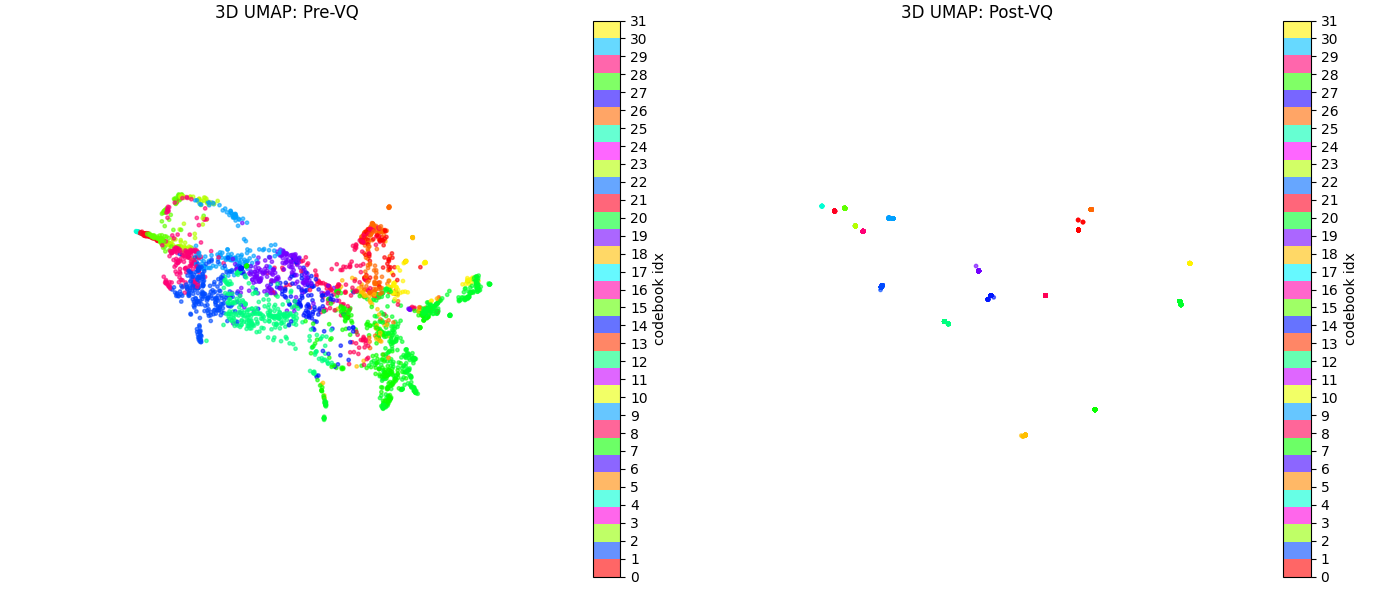

In [8]:
# 7b) 3-D UMAP instead of 2-D
reducer3d = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=3,
    random_state=42
)
emb_pre_3d  = reducer3d.fit_transform(pre_flat)    # (N,3)
emb_post_3d = reducer3d.transform(post_flat)       # (N,3)

# %% 
# 8b) Plot side by side in 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14,6))

ax = fig.add_subplot(121, projection='3d')
p = ax.scatter(
    emb_pre_3d[:,0], emb_pre_3d[:,1], emb_pre_3d[:,2],
    c=code_idxs, cmap=cmap, vmin=0, vmax=K-1,
    s=6, alpha=0.6
)
ax.set_title("3D UMAP: Pre-VQ")
ax.set_axis_off()
fig.colorbar(p, ax=ax, ticks=np.arange(K), label="codebook idx")

ax2 = fig.add_subplot(122, projection='3d')
p2 = ax2.scatter(
    emb_post_3d[:,0], emb_post_3d[:,1], emb_post_3d[:,2],
    c=code_idxs, cmap=cmap, vmin=0, vmax=K-1,
    s=6, alpha=0.6
)
ax2.set_title("3D UMAP: Post-VQ")
ax2.set_axis_off()
fig.colorbar(p2, ax=ax2, ticks=np.arange(K), label="codebook idx")

plt.tight_layout()
plt.show()